In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import NullLocator
from scipy.stats import mannwhitneyu
from tqdm import trange
import matplotlib.colors as mcolors
from tqdm import tqdm, trange
from scipy.stats import mannwhitneyu
from scipy.stats import fisher_exact
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from typing import Dict, Optional

DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"
DATA_PATH3 = "../../16-Y2H-data/processed-data/"
ABUNDANCE  = f"{DATA_PATH1}/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [2]:
# load the datasets with node centrality information and get nodes in both
ms_nodes = pd.read_pickle(f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl")
y2h_nodes = pd.read_csv(f"{DATA_PATH3}Y2H-s288c-step16.csv")

shared_nodes = set(ms_nodes["node"]) & set(y2h_nodes["node"])
print (f"A total of {len(shared_nodes)} nodes are shared between the MS and Y2H networks")

A total of 1465 nodes are shared between the MS and Y2H networks


In [3]:
# determine which nodes are hubs based on percentile cutoff for b centrality
cut = 0.10
ms_threshold = ms_nodes['betweenness_centrality'].quantile(1 - cut)
ms_hubs     = ms_nodes[ms_nodes['betweenness_centrality'] >= ms_threshold]
ms_nothub   = ms_nodes[ms_nodes['betweenness_centrality'] <  ms_threshold]

y2h_threshold = ms_nodes['Y2H_betweenness_centrality'].quantile(1 - cut)
y2h_hubs      = ms_nodes[ms_nodes['Y2H_betweenness_centrality'] >= y2h_threshold]
y2h_nothub    = ms_nodes[ms_nodes['Y2H_betweenness_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.00178; there are 393 hubs and 3534 non hubs
Threshold for defining a hub in Y2H data is 0.00388; there are 147 hubs and 1318 non hubs


## Supplement 1
* Create boxplots of protein half-life (min) for bottlenecks and non-bottlenecks in mass spec and Y2H datasets (hubs and non-hubs based on betweenness centrality)

In [4]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid huge memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

def clean_for_log(s):
    return (
        s.replace([np.inf, -np.inf], np.nan)
         .dropna()
         .loc[lambda x: x > 0]
    )
    
ms_nothub_vals  = clean_for_log(ms_nothub["Villen_halflife_min"])
ms_hub_vals     = clean_for_log(ms_hubs["Villen_halflife_min"])
y2h_nothub_vals = clean_for_log(y2h_nothub["Villen_halflife_min"])
y2h_hub_vals    = clean_for_log(y2h_hubs["Villen_halflife_min"])

groups = [
    ("MS hubs",      ms_hub_vals,     MS_COLOR),
    ("MS non-hubs",  ms_nothub_vals,  MS_COLOR),
    ("Y2H hubs",     y2h_hub_vals,    Y2H_COLOR),
    ("Y2H non-hubs", y2h_nothub_vals, Y2H_COLOR),
]

medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:15<00:00, 63815.24it/s]


MS hubs: median=126.90, 95% CI=(119.40, 135.60), n=328)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:37<00:00, 26870.45it/s]


MS non-hubs: median=130.20, 95% CI=(127.20, 132.60), n=2382)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 76103.71it/s]


Y2H hubs: median=141.60, 95% CI=(134.40, 151.20), n=101)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:22<00:00, 43601.26it/s]

Y2H non-hubs: median=132.90, 95% CI=(129.60, 136.80), n=946)


In [5]:
# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="two-sided")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="two-sided")

print("=== Mann–Whitney U tests on Villen_halflife_min ===")

print("\nMS bottlenecks vs MS non-bottlenecks")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

print("\nY2H bottlenecks vs Y2H bottlenecks")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

# MS: hubs vs non-hubs
ms_u, ms_p = mannwhitneyu(ms_hub_vals, ms_nothub_vals, alternative="less")

# Y2H: hubs vs non-hubs
y2h_u, y2h_p = mannwhitneyu(y2h_hub_vals, y2h_nothub_vals, alternative="less")

print("=== Mann–Whitney U tests on Villen_halflife_min ===")

print("\nMS bottlenecks vs MS non-bottlenecks")
print(f"n(hubs) = {len(ms_hub_vals)}, n(non-hubs) = {len(ms_nothub_vals)}")
print(f"median(hubs) = {np.median(ms_hub_vals):.2f}, median(non-hubs) = {np.median(ms_nothub_vals):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

print("\nY2H bottlenecks vs Y2H bottlenecks")
print(f"n(hubs) = {len(y2h_hub_vals)}, n(non-hubs) = {len(y2h_nothub_vals)}")
print(f"median(hubs) = {np.median(y2h_hub_vals):.2f}, median(non-hubs) = {np.median(y2h_nothub_vals):.2f}")
print(f"U = {y2h_u:.2f}, p = {y2h_p:.4g}")

=== Mann–Whitney U tests on Villen_halflife_min ===

MS bottlenecks vs MS non-bottlenecks
n(hubs) = 328, n(non-hubs) = 2382
median(hubs) = 126.90, median(non-hubs) = 130.20
U = 369639.50, p = 0.1138

Y2H bottlenecks vs Y2H bottlenecks
n(hubs) = 101, n(non-hubs) = 946
median(hubs) = 141.60, median(non-hubs) = 132.90
U = 54499.00, p = 0.0199
=== Mann–Whitney U tests on Villen_halflife_min ===

MS bottlenecks vs MS non-bottlenecks
n(hubs) = 328, n(non-hubs) = 2382
median(hubs) = 126.90, median(non-hubs) = 130.20
U = 369639.50, p = 0.05691

Y2H bottlenecks vs Y2H bottlenecks
n(hubs) = 101, n(non-hubs) = 946
median(hubs) = 141.60, median(non-hubs) = 132.90
U = 54499.00, p = 0.9901


/tmp/ipykernel_557/927864531.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


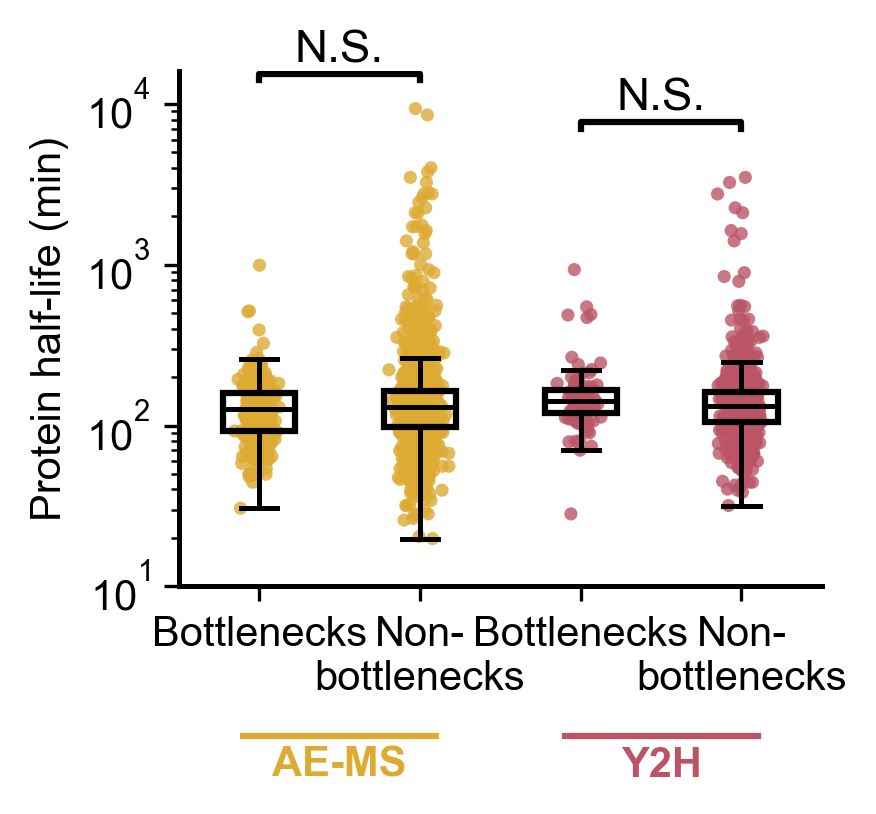

In [6]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y * 1.1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )

fig, ax = plt.subplots(figsize=(3, 3))

group_vals   = [ms_hub_vals, ms_nothub_vals, y2h_hub_vals, y2h_nothub_vals]
group_colors = [MS_COLOR,    MS_COLOR,       Y2H_COLOR,    Y2H_COLOR]

# --- Scatter first (lower zorder) ---
for i, (vals, color) in enumerate(zip(group_vals, group_colors), start=1):
    x_jitter = i + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Bottlenecks", "Non-\nbottlenecks", "Bottlenecks", "Non-\nbottlenecks"],
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_yscale("log")
ax.set_ylim(12, 16000)

ax.set_ylabel("Protein half-life (min)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ms_pair_max  = max(ms_hub_vals.max(), ms_nothub_vals.max())
y2h_pair_max = max(y2h_hub_vals.max(), y2h_nothub_vals.max())

#ms_y  = ms_pair_max * 2.0
ms_y  = 14000
y2h_y = y2h_pair_max * 2.0

add_bracket_with_text(ax, 1, 2, ms_y,  "N.S.")
add_bracket_with_text(ax, 3, 4, y2h_y, "N.S.")

# === Horizontal lines + labels under the groups ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()  # x in data coords, y in axis fraction (0–1)

# AE-MS under boxes 1–2
ax.plot(
    [0.9, 2.1], [-0.29, -0.29],
    transform=trans,
    clip_on=False,
    color=MS_COLOR,
    lw=1.5,
)
ax.text(
    1.5, -0.31, "AE-MS",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=MS_COLOR,
)

# Y2H under boxes 3–4
ax.plot(
    [2.9, 4.1], [-0.29, -0.29],
    transform=trans,
    clip_on=False,
    color=Y2H_COLOR,
    lw=1.5,
)
ax.text(
    3.5, -0.31, "Y2H",
    transform=trans,
    ha="center",
    va="top",
    fontsize=10,
    fontweight="bold",
    color=Y2H_COLOR,
)
ax.tick_params(axis="x", labelsize=8)
for label in ax.get_xticklabels():
    label.set_rotation(0)   # or 45
    label.set_ha("center")
    label.set_fontsize(10)
plt.yticks([10, 100, 1000, 10000])
plt.tight_layout()
plt.savefig("Supp1-1.svg")
plt.show()

## Supplement 2
Create boxplots for bottlenecks and non-bottlenecks in mass spec and Y2H datasets (hubs and non-hubs based on betweenness centrality)

In [7]:
def bootstrap_ct_fast(
    df: pd.DataFrame,
    col1: str,
    col2: str,
    n: Optional[int] = None,
    B: int = 1_000_000,
    alpha: float = 0.05,
    seed: Optional[int] = 0,
    correction: float = 0.0,   
) -> Dict[str, object]:
    
    sub = df[[col1, col2]].dropna().astype(bool)
    N = len(sub)
    if N == 0:
        raise ValueError("No rows after dropping NA.")
    if n is None:
        n = N

    # observed counts
    a = int(((sub[col1]) & (sub[col2])).sum())              # True, True
    b = int(((sub[col1]) & (~sub[col2])).sum())             # True, False
    c = int(((~sub[col1]) & (sub[col2])).sum())             # False, True
    d = int(((~sub[col1]) & (~sub[col2])).sum())            # False, False

    table = np.array([[a, b],
                      [c, d]], dtype=int)

    # "Observed" odds ratio from Fisher's exact test (fine to do once)
    odds_ratio_fisher, p_value = fisher_exact(table, alternative="two-sided")

    # Also compute the standard cross-product OR (used for bootstrap below)
    or_obs = ((a + correction) * (d + correction)) / ((b + correction) * (c + correction))
    odds1_obs = (a + correction) / (b + correction)
    odds2_obs = (c + correction) / (d + correction)

    # Multinomial probabilities from empirical distribution
    p = np.array([a, b, c, d], dtype=float) / N

    rng = np.random.default_rng(seed)

    # Draw all bootstrap tables at once (very fast)
    boot = rng.multinomial(n, p, size=B).astype(np.int32)
    boot_a, boot_b, boot_c, boot_d = boot.T  # each is (B,)

    # Vectorized odds / OR with correction
    boot_odds1 = (boot_a + correction) / (boot_b + correction)
    boot_odds2 = (boot_c + correction) / (boot_d + correction)
    boot_or    = ((boot_a + correction) * (boot_d + correction)) / ((boot_b + correction) * (boot_c + correction))

    # percentile CIs
    lo_q = alpha / 2
    hi_q = 1 - alpha / 2

    def ci(x: np.ndarray):
        return (float(np.quantile(x, lo_q)), float(np.quantile(x, hi_q)))

    a_ci = ci(boot_a); b_ci = ci(boot_b); c_ci = ci(boot_c); d_ci = ci(boot_d)
    odds1_ci = ci(boot_odds1); odds2_ci = ci(boot_odds2); or_ci = ci(boot_or)

    return {
        "a": a, "b": b, "c": c, "d": d,
        "a_lower": a_ci[0], "a_upper": a_ci[1],
        "b_lower": b_ci[0], "b_upper": b_ci[1],
        "c_lower": c_ci[0], "c_upper": c_ci[1],
        "d_lower": d_ci[0], "d_upper": d_ci[1],

        # Fisher OR / p-value for the observed table 
        "odds_ratio_fisher": float(odds_ratio_fisher),
        "p_value_fisher": float(p_value),

        # bootstrap distribution information for the cross-product OR and per-row odds
        "odds_ratio": float(or_obs), "odds_ratio_lower": or_ci[0], "odds_ratio_upper": or_ci[1],
        "row1_odds": float(odds1_obs), "row1_odds_lower": odds1_ci[0], "row1_odds_upper": odds1_ci[1],
        "row2_odds": float(odds2_obs), "row2_odds_lower": odds2_ci[0], "row2_odds_upper": odds2_ci[1],

    }

In [8]:
# convert your hub tables into boolean columns
ms_nodes = ms_nodes.copy()

ms_nodes["ms_hubs"]  = ms_nodes["node"].isin(ms_hubs["node"])
ms_nodes["y2h_hubs"] = ms_nodes["node"].isin(y2h_hubs["node"])

groups = [
    ("MS hubs",  "ms_hubs",  MS_COLOR),
    ("Y2H hubs", "y2h_hubs", Y2H_COLOR),
]

# Bootstrap + Fisher for both networks
results_ms = bootstrap_ct_fast(
    ms_nodes,
    col1="ms_hubs",
    col2="essential",
    n=None,
    B=1_000_000,
    alpha=0.05,
    seed=42,
    correction=0.5
)

print("\n" + "="*70)
print("MS NETWORK")
print("="*70)

print("Contingency table:")
print("                Essential     Non-essential")
print("Hub             {:>9d}          {:>9d}     ← a = hub & essential".format(
    results_ms['a'], results_ms['b']))
print("Non-hub         {:>9d}          {:>9d}     ← c = non-hub & essential".format(
    results_ms['c'], results_ms['d']))
print()

print("Fisher's exact test:")
print(f"  Odds ratio (hub vs non-hub) = {results_ms['odds_ratio_fisher']:.3f}")
print(f"  p-value                     = {results_ms['p_value_fisher']:.4g}")
print()

print("Bootstrap conditional odds (with Haldane–Anscombe correction):")
print(f"  Odds(essential | MS hub)     = {results_ms['row1_odds']:.3f}")
print(f"    95% CI                     = {results_ms['row1_odds_lower']:.3f} – {results_ms['row1_odds_upper']:.3f}")
print(f"  Odds(essential | MS non-hub) = {results_ms['row2_odds']:.3f}")
print(f"    95% CI                     = {results_ms['row2_odds_lower']:.3f} – {results_ms['row2_odds_upper']:.3f}")
print()

if results_ms['row1_odds'] > results_ms['row2_odds']:
    print("→ Essential proteins are enriched among MS hubs compared to non-hubs")
else:
    print("→ Essential proteins are NOT enriched among MS hubs (or depleted)")
print("-"*70)

results_y2h = bootstrap_ct_fast(
    ms_nodes,
    col1="y2h_hubs",
    col2="essential",
    n=None,
    B=1_000_000,
    alpha=0.05,
    seed=42,
    correction=0.5
)


print("\n" + "="*70)
print("Y2H NETWORK")
print("="*70)

print("Contingency table:")
print("                Essential     Non-essential")
print("Hub             {:>9d}          {:>9d}     ← a = hub & essential".format(
    results_y2h['a'], results_y2h['b']))
print("Non-hub         {:>9d}          {:>9d}     ← c = non-hub & essential".format(
    results_y2h['c'], results_y2h['d']))
print()

print("Fisher's exact test:")
print(f"  Odds ratio (hub vs non-hub) = {results_y2h['odds_ratio_fisher']:.3f}")
print(f"  p-value                     = {results_y2h['p_value_fisher']:.4g}")
print()

print("Bootstrap conditional odds (with Haldane–Anscombe correction):")
print(f"  Odds(essential | Y2H hub)     = {results_y2h['row1_odds']:.3f}")
print(f"    95% CI                      = {results_y2h['row1_odds_lower']:.3f} – {results_y2h['row1_odds_upper']:.3f}")
print(f"  Odds(essential | Y2H non-hub) = {results_y2h['row2_odds']:.3f}")
print(f"    95% CI                      = {results_y2h['row2_odds_lower']:.3f} – {results_y2h['row2_odds_upper']:.3f}")
print()

if results_y2h['row1_odds'] > results_y2h['row2_odds']:
    print("→ Essential proteins are enriched among Y2H hubs compared to non-hubs")
else:
    print("→ Essential proteins are NOT enriched among Y2H hubs (or depleted)")
print("-"*70)



# Extract the four conditional odds + CIs
# MS
odds_ms_hub_ess     = results_ms["row1_odds"]          # essential | MS hub
odds_ms_nonhub_ess  = results_ms["row2_odds"]          # essential | not MS hub
ci_ms_hub_ess       = [results_ms["row1_odds_lower"], results_ms["row1_odds_upper"]]
ci_ms_nonhub_ess    = [results_ms["row2_odds_lower"], results_ms["row2_odds_upper"]]

# Y2H
odds_y2h_hub_ess    = results_y2h["row1_odds"]         # essential | Y2H hub
odds_y2h_nonhub_ess = results_y2h["row2_odds"]         # essential | not Y2H hub
ci_y2h_hub_ess      = [results_y2h["row1_odds_lower"], results_y2h["row1_odds_upper"]]
ci_y2h_nonhub_ess   = [results_y2h["row2_odds_lower"], results_y2h["row2_odds_upper"]]

# Print results 
def print_odds_result(name, odds_hub, ci_hub, odds_nonhub, ci_nonhub):
    print(f"\n{name}:")
    print(f"  Odds essential | hub      = {odds_hub:.2f}  (95% CI: {ci_hub[0]:.2f} – {ci_hub[1]:.2f})")
    print(f"  Odds essential | non-hub  = {odds_nonhub:.2f}  (95% CI: {ci_nonhub[0]:.2f} – {ci_nonhub[1]:.2f})")
    diff = odds_hub - odds_nonhub
    direction = "higher" if diff > 0 else "lower"
    print(f"  → Essential proteins are {direction} in hubs than in non-hubs")

print_odds_result("MS", odds_ms_hub_ess, ci_ms_hub_ess, odds_ms_nonhub_ess, ci_ms_nonhub_ess)
print_odds_result("Y2H", odds_y2h_hub_ess, ci_y2h_hub_ess, odds_y2h_nonhub_ess, ci_y2h_nonhub_ess)


MS NETWORK
Contingency table:
                Essential     Non-essential
Hub                   148                245     ← a = hub & essential
Non-hub               874               2660     ← c = non-hub & essential

Fisher's exact test:
  Odds ratio (hub vs non-hub) = 1.839
  p-value                     = 8.325e-08

Bootstrap conditional odds (with Haldane–Anscombe correction):
  Odds(essential | MS hub)     = 0.605
    95% CI                     = 0.491 – 0.739
  Odds(essential | MS non-hub) = 0.329
    95% CI                     = 0.304 – 0.354

→ Essential proteins are enriched among MS hubs compared to non-hubs
----------------------------------------------------------------------

Y2H NETWORK
Contingency table:
                Essential     Non-essential
Hub                    55                 92     ← a = hub & essential
Non-hub               967               2813     ← c = non-hub & essential

Fisher's exact test:
  Odds ratio (hub vs non-hub) = 1.739
  p-value         

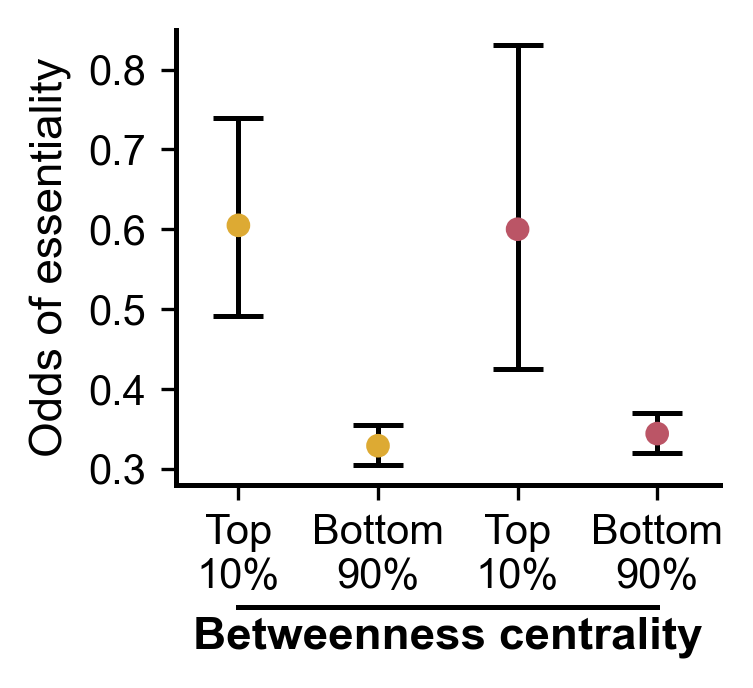

In [9]:
# Prepare data for plotting ODDS RATIOS
odds_values = np.array([
    odds_ms_hub_ess,
    odds_ms_nonhub_ess,
    odds_y2h_hub_ess,
    odds_y2h_nonhub_ess
])

ci_lower = np.array([
    ci_ms_hub_ess[0],
    ci_ms_nonhub_ess[0],
    ci_y2h_hub_ess[0],
    ci_y2h_nonhub_ess[0]
])

ci_upper = np.array([
    ci_ms_hub_ess[1],
    ci_ms_nonhub_ess[1],
    ci_y2h_hub_ess[1],
    ci_y2h_nonhub_ess[1]
])

yerr = np.vstack([odds_values - ci_lower, ci_upper - odds_values])

labels = [
    "Top\n10%",
    "Bottom\n90%",
    "Top\n10%",
    "Bottom\n90%"
]

colors = [MS_COLOR, MS_COLOR, Y2H_COLOR, Y2H_COLOR]
x_pos = np.array([1.8, 2.8, 3.8, 4.8])   # gap between MS and Y2H groups

fig, ax = plt.subplots(figsize=(2.6, 2.4))

# Points on top (colored)
ax.scatter(
    x=x_pos,
    y=odds_values,
    s=20,
    color=colors,
    #edgecolor="black",
    linewidth=1.2,
    zorder=3
)
# Add error bars
ax.errorbar(
    x=x_pos,
    y=odds_values,
    yerr=yerr,
    fmt="none",
    ecolor="black",
    linewidth=1.2,
    capsize=6,
    capthick=1.2,
    zorder=2
)

# ── Betweenness centrality line and label 
trans = ax.get_xaxis_transform()

# Labelling betweenness centrality
ax.plot(
    [1.8, 4.8], [-0.27, -0.27],
    transform=trans,
    clip_on=False,
    color='black',
    lw=1.2,
)
ax.text(
    3.3, -0.29, "Betweenness centrality",
    transform=trans,
    ha="center",
    va="top",
    fontsize=11,
    fontweight="bold",
    color='black',
)

# Axes and style
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=11, ha='center')
ax.margins(x=0.15)
ax.set_ylabel("Odds of essentiality", fontsize=11)
ax.set_ylim(0.28, 0.85)
ax.set_yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.tick_params(axis='both', labelsize=10)
plt.subplots_adjust(bottom=0.24)

plt.tight_layout()

plt.savefig("Supp1-2.svg", bbox_inches="tight", dpi=400)
plt.show()